<a href="https://colab.research.google.com/github/Aireenelz/WIE3007-DMW-Group6/blob/xgboost-modelling-joan/xgboost_modelling_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### XGBoost Feature Engineering
#### 1. Setup and Data Loading
##### - load the synthetic_financial_data into google colab
##### - initial observation of the dataset

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('synthetic_financial_data.csv')

# Quick look
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 22)


,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription
0,1,59,High School,Self-Employed,Technology,11,9067.159786,Single,2,Own with Mortgage,...,1583.065500,7,1,0,Personal,20789.005502,36,3.828919,0,Need funds for the next three years.
1,2,51,Below High School,Full-Time,Government,24,5068.058742,Married,1,Own with Mortgage,...,1332.052087,7,1,1,Personal,27461.583712,48,8.855769,1,I need a personal loan for this to be done.
2,3,24,Bachelor,Unemployed,Manufacturing,0,2557.541824,Single,0,Living with Parents,...,911.536097,2,1,1,Business,68862.744645,240,14.748993,1,Seeking financing to start my own company.
3,4,25,Bachelor,Full-Time,Finance,0,7535.097299,Single,0,Living with Parents,...,514.141526,6,1,0,Wedding,8841.450954,48,4.825886,0,I need a personal loan for me.
4,5,25,Master,Part-Time,Government,5,4798.465251,Married,2,Rent,...,2386.488285,3,0,1,Education,17787.927594,120,18.384157,1,"Applying for student financing for tuition, fe..."


#### 2. Small Language Models (SLM) Feature Extraction
##### - use DistillBERT model for sentiment analysis of column 'LoanPurposeDescription'
##### - create a new column 'Sentiment_Feature' that categorize the 'LoanPurposeDescription' into 'POSITIVE', 'NEGATIVE, and 'NEUTRAL'


In [ ]:
# import necessary library
from transformers import pipeline

# Load a lightweight sentiment model (distillbert model) for sentiment analysis
sentiment_task = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
# sentiment-analysis: tell the model we want sentiment analysis so it looks for positive or negative emotions in text

# get_sentiment: function to process text
def get_sentiment(text):
    # if a row has no text, just mark it as "NEUTRAL"
    if pd.isna(text) or text == "": return "NEUTRAL"
    # [:512]: the limit because BER-style model can only read 512 characters at a time
    # ['label']: The model returns a lot of data, but we only want the 'label' (e.g., "POSITIVE" or "NEGATIVE").
    return sentiment_task(text[:512])[0]['label']

# create a new column 'Sentiment_Feature'
# it takes the text in LoanPurposeDescription and converts it into a category
df['Original_Sentiment_Feature'] = df['LoanPurposeDescription'].apply(get_sentiment)
print(df['Original_Sentiment_Feature'].value_counts())
df[['LoanPurposeDescription', 'Original_Sentiment_Feature']].head(10)

Device set to use cuda:0


Original_Sentiment_Feature
NEGATIVE    872
NEUTRAL      66
POSITIVE     62
Name: count, dtype: int64


,LoanPurposeDescription,Original_Sentiment_Feature
0,Need funds for the next three years.,NEGATIVE
1,I need a personal loan for this to be done.,NEGATIVE
2,Seeking financing to start my own company.,NEGATIVE
3,I need a personal loan for me.,NEGATIVE
4,"Applying for student financing for tuition, fe...",NEGATIVE
5,Applying for financing to cover the cost of th...,NEGATIVE
6,I need a personal loan for me.,NEGATIVE
7,Applying for financing to cover the costs of t...,NEGATIVE
8,Applying for financing to cover the costs of t...,NEGATIVE
9,I need a personal loan for me to take care of ...,NEGATIVE


##### It is very common for financial datasets to lean "negative" when using general sentiment models because words like "Debt," "Emergency," or "Loan" are often flagged as negative.

To get a better mix of Positive, Negative, and Neutral, a Keyword-Augmented Logic is used.

The Strategy:
- Neutral: Keep NaN as Neutral.

- Positive Keywords: If words like "Growth," "Expansion," "Investment," or "Success" appear, we nudge the result to Positive.

- Negative Keywords: If words like "Struggling," "Debt," "Emergency," or "Late" appear, we nudge it to Negative.

- AI Fallback: If no keywords are found, we let the DistilBERT model decide.

In [ ]:
# improve the sentiment analysis

# import necessary library
from transformers import pipeline

# Load a lightweight sentiment model (distillbert model) for sentiment analysis
sentiment_task = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
# sentiment-analysis: tell the model we want sentiment analysis so it looks for positive or negative emotions in text

# get_sentiment: function to process text
def get_improved_sentiment(text):
    # # if a row has no text, just mark it as "NEUTRAL"
    if pd.isna(text) or text == "" or text == "None":
        return "NEUTRAL"

    text_lower = str(text).lower()

    # define Financial Keywords
    positive_words = ['business', 'expand', 'opportunity','student', 'starting', 'future','career','education','new']
    negative_words = ['struggling', 'debt', 'emergency', 'overdue', 'bills', 'medical', 'crisis', 'urgent']

    # keyword
    if any(word in text_lower for word in positive_words):
        return "POSITIVE"
    if any(word in text_lower for word in negative_words):
        return "NEGATIVE"

    # AI Fallback (If no keywords found, let the model decide)
    try:
        result = sentiment_task(text[:512])[0]['label']
        return result
    except:
        return "NEUTRAL"

# Apply the function
df['Sentiment_Feature'] = df['LoanPurposeDescription'].apply(get_improved_sentiment)

print(df['Sentiment_Feature'].value_counts())
df[['LoanPurposeDescription', 'Sentiment_Feature']].head(10)

Device set to use cuda:0


Sentiment_Feature
NEGATIVE    634
POSITIVE    300
NEUTRAL      66
Name: count, dtype: int64


,LoanPurposeDescription,Sentiment_Feature
0,Need funds for the next three years.,NEGATIVE
1,I need a personal loan for this to be done.,NEGATIVE
2,Seeking financing to start my own company.,NEGATIVE
3,I need a personal loan for me.,NEGATIVE
4,"Applying for student financing for tuition, fe...",POSITIVE
5,Applying for financing to cover the cost of th...,NEGATIVE
6,I need a personal loan for me.,NEGATIVE
7,Applying for financing to cover the costs of t...,NEGATIVE
8,Applying for financing to cover the costs of t...,NEGATIVE
9,I need a personal loan for me to take care of ...,NEGATIVE


#### 3. AI-Driven Risk Categorization using Zero-Shot Classification Pipeline (BART-Large)
##### - Zero-Shot Classification: this model compares the "meaning" of the loan description to the "meaning" of your labels.
##### - The Keyword Layer: add a manual check for words like "crisis" or "expansion." This acts as a "Financial Expert" rule-base, which makes the model more reliable for banking data.

In [ ]:
# load the Zero-Shot Classification Pipeline (BART-Large)
risk_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

def get_risk_category(text):
    # Handle missing data
    if pd.isna(text) or text == "" or text == "None":
        return "UNKNOWN"

    text_lower = str(text).lower()

    # Financial Domain Keywords (Fast Logic)
    high_risk_words = ['emergency', 'medical', 'struggling', 'bills', 'overdue', 'debt', 'urgent', 'crisis']
    low_risk_words = ['expansion', 'investment', 'growth', 'business', 'mortgage', 'assets', 'startup']

    if any(word in text_lower for word in high_risk_words):
        return "HIGH RISK"
    if any(word in text_lower for word in low_risk_words):
        return "LOW RISK"

    # AI Fallback (For descriptions that are hard to judge)
    try:
        candidate_labels = ["high risk", "medium risk", "low risk"]
        result = risk_classifier(text[:512], candidate_labels)
        return result['labels'][0].upper() # Returns the label with the highest score
    except:
        return "MEDIUM RISK"

# Apply the risk categorization (Applying to all, but AI part only triggers if keywords fail)
df['AI_Risk_Category'] = df['LoanPurposeDescription'].apply(get_risk_category)

# Check the results
print(df['AI_Risk_Category'].value_counts())
df[['LoanPurposeDescription', 'AI_Risk_Category']].head(10)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


AI_Risk_Category
MEDIUM RISK    439
HIGH RISK      353
LOW RISK       142
UNKNOWN         66
Name: count, dtype: int64


,LoanPurposeDescription,AI_Risk_Category
0,Need funds for the next three years.,MEDIUM RISK
1,I need a personal loan for this to be done.,HIGH RISK
2,Seeking financing to start my own company.,MEDIUM RISK
3,I need a personal loan for me.,MEDIUM RISK
4,"Applying for student financing for tuition, fe...",MEDIUM RISK
5,Applying for financing to cover the cost of th...,HIGH RISK
6,I need a personal loan for me.,MEDIUM RISK
7,Applying for financing to cover the costs of t...,HIGH RISK
8,Applying for financing to cover the costs of t...,HIGH RISK
9,I need a personal loan for me to take care of ...,HIGH RISK


#### 4. Preprocessing
##### After extracting AI features (Sentiment and Risk), we need to prepare the entire dataset for the XGBoost model.

#####- Label Encoding: XGBoost is a mathematical algorithm; it only understands numbers. We need to encode the data.
##### - Train-Test Split: split the data into a Training Set (to teach the model) and a Testing Set (to see if it actually learned).

In [ ]:
df_dropped = df.drop(columns=['Original_Sentiment_Feature'])

In [ ]:
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Age                     1000 non-null   int64  
 2   Education               1000 non-null   object 
 3   EmploymentType          1000 non-null   object 
 4   EmploymentSector        1000 non-null   object 
 5   EmploymentLengthYears   1000 non-null   int64  
 6   MonthlyIncome           1000 non-null   float64
 7   MaritalStatus           1000 non-null   object 
 8   Dependents              1000 non-null   int64  
 9   PropertyOwnership       1000 non-null   object 
 10  CreditScore             1000 non-null   int64  
 11  ExistingLoans           1000 non-null   int64  
 12  MonthlyDebt             1000 non-null   float64
 13  YearsWithBank           1000 non-null   int64  
 14  HasSavingsAccount       1000 non-null   i

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Identify your columns
# Categorical columns need to be turned into numbers
categorical_cols = [
    'Education', 'EmploymentType', 'EmploymentSector', 'MaritalStatus',
    'PropertyOwnership','LoanPurpose', 'LoanPurposeDescription', 'Sentiment_Feature', 'AI_Risk_Category'
]

# Numerical columns stay as they are
numerical_cols = [
    'CustomerID','Age', 'EmploymentLengthYears', 'MonthlyIncome', 'Dependents',
    'CreditScore', 'ExistingLoans', 'MonthlyDebt', 'YearsWithBank', 'HasSavingsAccount',
    'HasCheckingAccount','LoanAmount', 'LoanTermMonths', 'InterestRate'
]

# Label Encoding
# This turns "High Risk" -> 2, "Medium Risk" -> 1, "Low Risk" -> 0
le = LabelEncoder()
for col in categorical_cols:
    df_dropped[col] = le.fit_transform(df_dropped[col].astype(str))

# Define X (Features) and y (Target)
X = df_dropped[numerical_cols + categorical_cols]
y = df_dropped['LoanDefault'] # This is what we want to predict

# Split the Data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
X_train.head()

Training rows: 800
Testing rows: 200


,CustomerID,Age,EmploymentLengthYears,MonthlyIncome,Dependents,CreditScore,ExistingLoans,MonthlyDebt,YearsWithBank,HasSavingsAccount,...,InterestRate,Education,EmploymentType,EmploymentSector,MaritalStatus,PropertyOwnership,LoanPurpose,LoanPurposeDescription,Sentiment_Feature,AI_Risk_Category
29,30,54,11,6524.890658,0,672,1,2141.432699,12,1,...,8.148805,3,1,3,0,2,3,290,2,2
535,536,21,0,1604.272714,0,553,2,551.021990,2,1,...,13.011506,0,4,5,2,0,2,76,0,0
695,696,66,30,7677.177003,0,752,1,455.796929,17,1,...,3.656724,1,1,7,0,2,9,263,0,2
557,558,19,0,722.143859,0,584,2,347.105904,1,1,...,14.422989,2,2,2,2,0,3,392,2,1
836,837,67,20,9672.124896,3,758,2,971.675691,8,1,...,5.343914,1,1,5,1,1,0,555,1,3


#### 5. Export the preprocessed data

In [ ]:
# Save the preprocessed data to a CSV
df_dropped.to_csv('preprocessed_financial_data.csv', index=False)

print("File saved.")

File saved.


###XGBoost Model Development
#### 1. Data Loading and Train-Test Split

In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Load the preprocessed data
df = pd.read_csv('preprocessed_financial_data.csv')

# Separate features (X) and target (y)
# drop 'LoanDefault' because it's the answer, and 'LoanPurposeDescription' because it's text
X = df.drop(columns=['LoanDefault', 'LoanPurposeDescription', 'CustomerID'], errors='ignore')
y = df['LoanDefault']

# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 2.1 Underfit XGBoost Model
##### - make the model underfit by setting a very low n_estimators (few trees) and a very shallow max_depth (simple trees)

In [2]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score

# Initialize Underfit Model
# Very few trees and very shallow depth -> can't learn complex patterns
model_underfit = xgb.XGBClassifier(
    n_estimators=2,
    max_depth=1,
    learning_rate=0.01,
    random_state=42
)

model_underfit.fit(X_train, y_train)

# Evaluate
train_pred_un = model_underfit.predict(X_train)
test_pred_un = model_underfit.predict(X_test)

train_accuracy_xgb_underfit = accuracy_score(y_train, train_pred_un)
test_accuracy_xgb_underfit = accuracy_score(y_test, test_pred_un)

print(f"Underfitting Results:")
print(f"Train Accuracy: {train_accuracy_xgb_underfit:.4f}")
print(f"Test Accuracy: {test_accuracy_xgb_underfit:.4f}")
print(f"Underfitting Gap: {train_accuracy_xgb_underfit - test_accuracy_xgb_underfit:.4f}")

print("\nclassification Report (Training):")
print(classification_report(y_train, train_pred_un))

print("\nclassification Report (Testing):")
print(classification_report(y_test, test_pred_un))

Underfitting Results:
Train Accuracy: 0.5100
Test Accuracy: 0.4600
Underfitting Gap: 0.0500

classification Report (Training):
              precision    recall  f1-score   support

           0       0.51      1.00      0.68       408
           1       0.00      0.00      0.00       392

    accuracy                           0.51       800
   macro avg       0.26      0.50      0.34       800
weighted avg       0.26      0.51      0.34       800


classification Report (Testing):
              precision    recall  f1-score   support

           0       0.46      1.00      0.63        92
           1       0.00      0.00      0.00       108

    accuracy                           0.46       200
   macro avg       0.23      0.50      0.32       200
weighted avg       0.21      0.46      0.29       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

'\nprint("Underfitting Results:")\nprint(f"Train Accuracy: {accuracy_score(y_train, train_pred):.4f}")\nprint(f"Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")\n'

#### 2.2 Overfit XGBoost Model
##### - force overfitting by allowing the trees to grow infinitely deep and setting the learning rate high with no regularization

In [4]:
# Initialize Overfit Model
# Deep trees (max_depth=50) allow the model to memorize every single row
model_overfit = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=50,
    learning_rate=0.5,
    random_state=42
)

model_overfit.fit(X_train, y_train)

# Evaluate
train_pred_ov = model_overfit.predict(X_train)
test_pred_ov = model_overfit.predict(X_test)

train_accuracy_xgb_overfit = accuracy_score(y_train, train_pred_ov)
test_accuracy_xgb_overfit = accuracy_score(y_test, test_pred_ov)

print(f"Overfitting Results:")
print(f"Train Accuracy: {train_accuracy_xgb_overfit:.4f}")
print(f"Test Accuracy: {test_accuracy_xgb_overfit:.4f}")
print(f"Overfitting Gap: {train_accuracy_xgb_overfit - test_accuracy_xgb_overfit:.4f}")

print("\nclassification Report (Training):")
print(classification_report(y_train, train_pred_ov))

print("\nclassification Report (Testing):")
print(classification_report(y_test, test_pred_ov))

Overfitting Results:
Train Accuracy: 1.0000
Test Accuracy: 0.7300
Overfitting Gap: 0.2700

classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       408
           1       1.00      1.00      1.00       392

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


classification Report (Testing):
              precision    recall  f1-score   support

           0       0.69      0.74      0.72        92
           1       0.76      0.72      0.74       108

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200



#### 2.3 Optimal Fit XGBoost Model

##### - use "early stopping" or balanced parameters to find the best fit

In [5]:
# Initialize Optimal Model
model_optimal = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8, # Use only 80% of data per tree to prevent memorization
    colsample_bytree=0.8,
    random_state=42
)

model_optimal.fit(X_train, y_train)

# Evaluate
train_pred_opt = model_optimal.predict(X_train)
test_pred_opt = model_optimal.predict(X_test)

train_accuracy_xgb_opt = accuracy_score(y_train, train_pred_opt)
test_accuracy_xgb_opt = accuracy_score(y_test, test_pred_opt)

print(f"Optimal Results:")
print(f"Train Accuracy: {train_accuracy_xgb_opt:.4f}")
print(f"Test Accuracy: {test_accuracy_xgb_opt:.4f}")
print(f"Optimal Gap: {train_accuracy_xgb_opt - test_accuracy_xgb_opt:.4f}")

print("\nclassification Report (Training):")
print(classification_report(y_train, train_pred_opt))

print("\nclassification Report (Testing):")
print(classification_report(y_test, test_pred_opt))

Optimal Results:
Train Accuracy: 0.9850
Test Accuracy: 0.7450
Optimal Gap: 0.2400

classification Report (Training):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       408
           1       0.98      0.98      0.98       392

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800


classification Report (Testing):
              precision    recall  f1-score   support

           0       0.72      0.73      0.72        92
           1       0.77      0.76      0.76       108

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.75      0.74      0.75       200



#### 3. Performance Evaluation and AI Interpretation
#### 3.1 Performance Evaluation
- Accuracy: It tells you how many total loans (Default + Non-Default) were correctly classified. It is your "baseline" metric.

- F1-Score: This is critical because "Default" cases are usually rarer than "Normal" cases. F1-Score ignores the easy-to-predict "Normal" cases and focuses on how well you caught the "Defaults" without being overly sensitive.

- ROC-AUC: This tells you the model's "Separation Power." An AUC of 0.80 means there is an 80% chance that the model will be able to distinguish between a defaulter and a non-defaulter.

- RMSE: Usually used in regression, but in classification, we use it on the probability scores. It measures how "confident" the model was. A high RMSE means the model was "unsure" even when it was right.

Final Model Metrics
Accuracy:  0.7450
F1-Score:  0.7628
ROC-AUC:   0.8418
RMSE:      0.4136


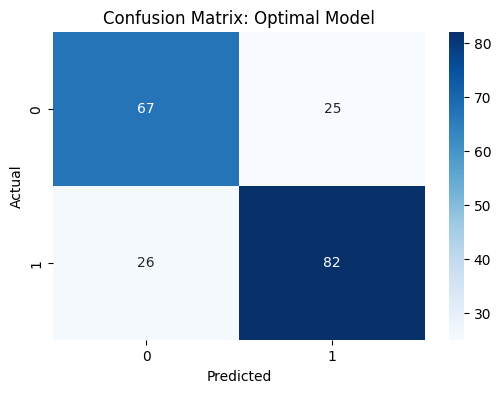

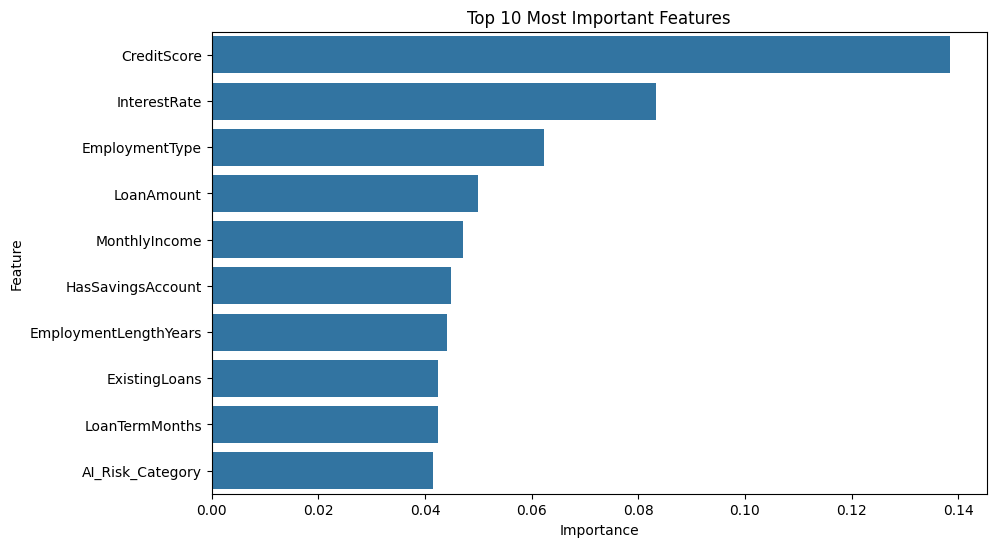

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_squared_error, confusion_matrix, roc_curve
)
import numpy as np

# Get Predictions and Probabilities
y_pred = model_optimal.predict(X_test)
y_probs = model_optimal.predict_proba(X_test)[:, 1] # Probability of 'Default'

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)
rmse = np.sqrt(mean_squared_error(y_test, y_probs)) # RMSE of probabilities

print(f"Final Model Metrics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"RMSE:      {rmse:.4f}")

# Visualization: Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Optimal Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importances = model_optimal.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

#### 3.2 AI Interpretation
#####- use lightweight DistillGPT2 model to interpret feature importance and generate a summary


In [7]:
from transformers import pipeline

# 1. Use a slightly more robust model for explanation (GPT-2)
# We set device=0 to use the GPU (cuda) for speed
summarizer = pipeline("text-generation", model="gpt2", device=0)

# 2. Get the top features dynamically from your dataframe
top_features = feature_importance_df.iloc[:3]['Feature'].tolist()

# 3. Create a more structured prompt
insight_prompt = (
    f"Predicting loan default depends on {top_features[0]}, {top_features[1]}, and {top_features[2]}. "
    f"The reason {top_features[0]} is important is because"
)

# 4. Generate with better settings
# max_new_tokens: gives it room to explain
# temperature: makes it a bit more creative/human-like
explanation = summarizer(
    insight_prompt,
    max_new_tokens=100,
    temperature=0.7,
    pad_token_id=50256
)

print("\n" + "="*30)
print("AI INTERPRETATION OF RESULTS")
print("="*30)
print(explanation[0]['generated_text'])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0



AI INTERPRETATION OF RESULTS
Predicting loan default depends on CreditScore, InterestRate, and EmploymentType. The reason CreditScore is important is because it is used to predict the likelihood that a loan will default. When you take a look at the credit score of one credit provider, you will see that there is a huge difference between the average loan default rate and the average interest rate. This means that those who are having trouble paying their loans will have a higher chance of defaulting.

But there is another reason to take interest rate risk. To see the risk of any default, you need to know the rate at which a loan is


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import json

# Paste the path you copied here
notebook_path = '/content/drive/MyDrive/Colab Notebooks/xgboost_modelling_v2.ipynb'

with open(notebook_path, 'r') as f:
    data = json.load(f)

if 'widgets' in data.get('metadata', {}):
    del data['metadata']['widgets']
    print("Success! Metadata cleaned.")

with open(notebook_path, 'w') as f:
    json.dump(data, f)

Success! Metadata cleaned.
